## HMM Assignment

In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal
from scipy.fft import fft, fftfreq
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from tqdm import tqdm
import warnings
import joblib
warnings.filterwarnings('ignore')

In [ ]:
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

BASE_PATH = PROJECT_ROOT / "Recordings"
PROCESSED_PATH = PROJECT_ROOT / "data_processed"
REPORT_PATH = PROJECT_ROOT / "report"

for p in [PROCESSED_PATH, REPORT_PATH]:
    p.mkdir(exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Found {len(list(BASE_PATH.glob('**/*.csv')))} CSV files")

example = next(BASE_PATH.glob("Walking/*/Accelerometer.csv"), None)
print(f"Example file: {example}")

Project Root: c:\Users\TestSolutions\Desktop\HMM-Assignment
Found 336 CSV files
Example file: c:\Users\TestSolutions\Desktop\HMM-Assignment\Recordings\Walking\2025-10-24_14-29-59\Accelerometer.csv


In [ ]:
walking_dirs = sorted((BASE_PATH / "Walking").glob("*"))
example_dir = walking_dirs[0]
print(f"Selected session: {example_dir.name}")
print(f"Path: {example_dir}")

acc_file = example_dir / "Accelerometer.csv"
gyro_file = example_dir / "Gyroscope.csv"

# Load CSVs
df_acc = pd.read_csv(acc_file)
df_gyro = pd.read_csv(gyro_file)

print(f"Accelerometer: {df_acc.shape[0]} rows")
print(f"Gyroscope:    {df_gyro.shape[0]} rows")

Selected session: 2025-10-24_14-29-59
Path: c:\Users\TestSolutions\Desktop\HMM-Assignment\Recordings\Walking\2025-10-24_14-29-59
Accelerometer: 645 rows
Gyroscope:    645 rows


In [ ]:
print("\nAccelerometer sample:")
display(df_acc.head(3))
print("\nGyroscope sample:")
display(df_gyro.head(3))


Accelerometer sample:


,time,seconds_elapsed,z,y,x
0,1761316199806164000,0.371164,-0.040770,0.041231,-0.107297
1,1761316199862932000,0.427932,0.066978,0.036301,0.098927
2,1761316199881854700,0.446855,0.119957,0.076618,0.060275



Gyroscope sample:


,time,seconds_elapsed,z,y,x
0,1761316199815625200,0.380625,-0.010461,0.044134,0.019776
1,1761316199862932000,0.427932,-0.005574,0.088115,0.017333
2,1761316199881854700,0.446855,-0.020234,0.073454,0.019776


In [ ]:
df_acc = pd.read_csv(acc_file)
df_gyro = pd.read_csv(gyro_file)

df_acc['seconds_elapsed'] = df_acc['seconds_elapsed'].round(6)
df_gyro['seconds_elapsed'] = df_gyro['seconds_elapsed'].round(6)

df_acc_sorted = df_acc.sort_values('seconds_elapsed')
df_gyro_sorted = df_gyro.sort_values('seconds_elapsed')

df_merged = pd.merge_asof(
    df_acc_sorted,
    df_gyro_sorted,
    on='seconds_elapsed',
    direction='nearest',
    tolerance=0.01
).dropna()

df_merged = df_merged.rename(columns={
    'x_x': 'acc_x', 'y_x': 'acc_y', 'z_x': 'acc_z',
    'x_y': 'gyro_x', 'y_y': 'gyro_y', 'z_y': 'gyro_z'
})

df_merged = df_merged.drop(columns=['time_x', 'time_y'], errors='ignore')

print("Merged columns:", df_merged.columns.tolist())
display(df_merged.head(3))

Merged columns: ['seconds_elapsed', 'acc_z', 'acc_y', 'acc_x', 'gyro_z', 'gyro_y', 'gyro_x']


,seconds_elapsed,acc_z,acc_y,acc_x,gyro_z,gyro_y,gyro_x
0,0.371164,-0.040770,0.041231,-0.107297,-0.010461,0.044134,0.019776
1,0.427932,0.066978,0.036301,0.098927,-0.005574,0.088115,0.017333
2,0.446855,0.119957,0.076618,0.060275,-0.020234,0.073454,0.019776


In [ ]:
time_diffs = np.diff(df_merged['seconds_elapsed'])
sampling_rate = 1.0 / np.median(time_diffs)
duration = df_merged['seconds_elapsed'].iloc[-1] - df_merged['seconds_elapsed'].iloc[0]

print(f"\nSAMPLING RATE: {sampling_rate:.2f} Hz")
print(f"DURATION: {duration:.1f} seconds")
print(f"TOTAL SAMPLES: {len(df_merged)}")


SAMPLING RATE: 52.85 Hz
DURATION: 12.2 seconds
TOTAL SAMPLES: 645


Plot saved: c:\Users\TestSolutions\Desktop\HMM-Assignment\report\fig_raw_signal_walking.png


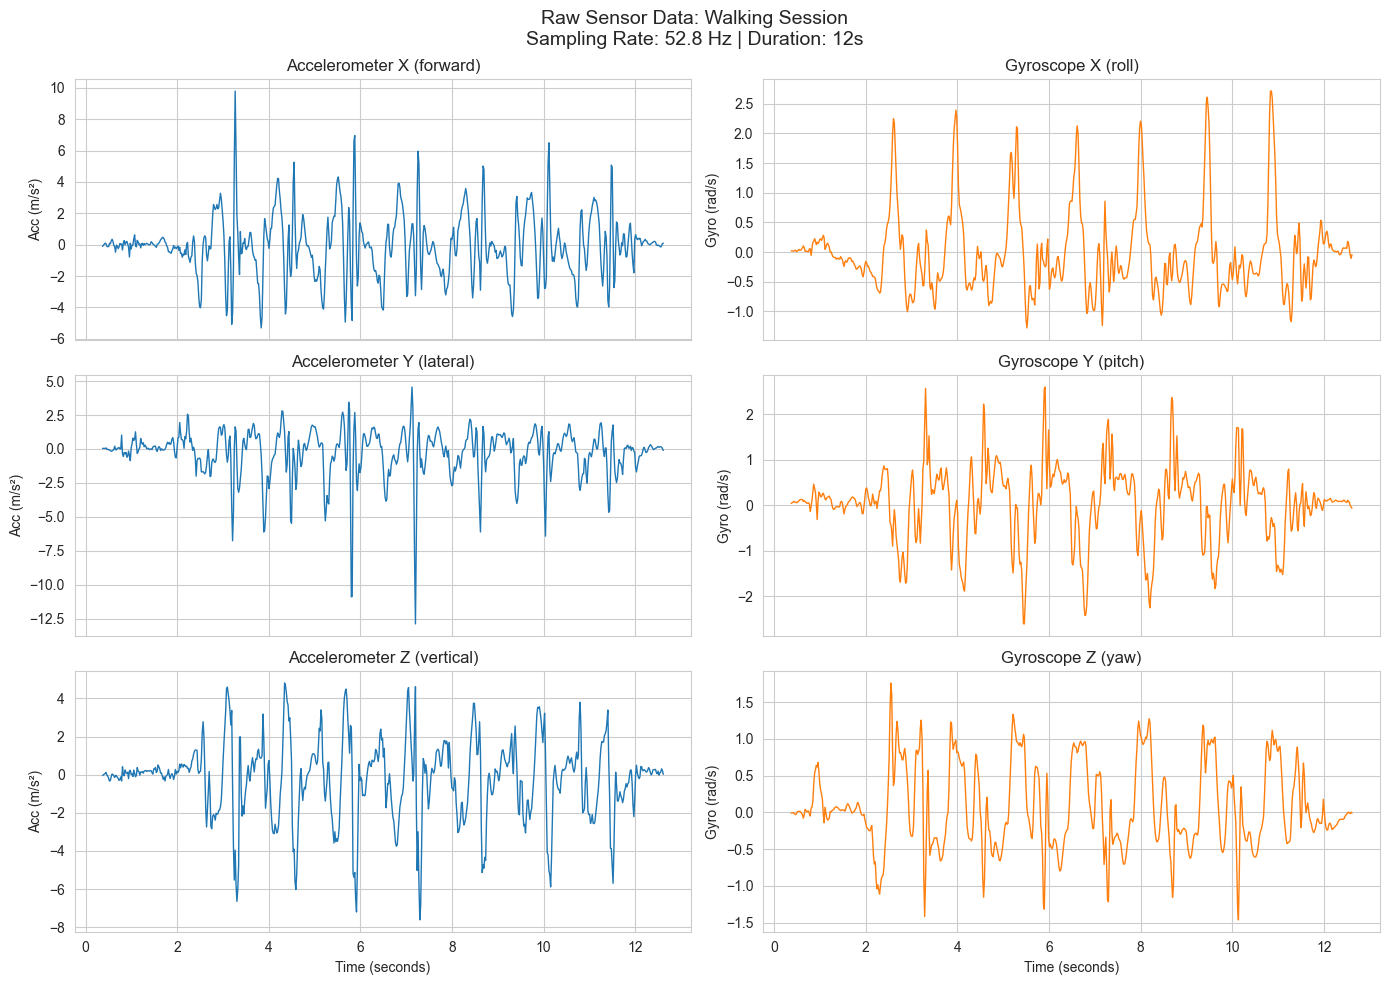

In [ ]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
t = df_merged['seconds_elapsed']

acc_axes = ['acc_x', 'acc_y', 'acc_z']
acc_labels = ['X (forward)', 'Y (lateral)', 'Z (vertical)']

for i, (col, label) in enumerate(zip(acc_axes, acc_labels)):
    axes[i, 0].plot(t, df_merged[col], label=f'{label}', linewidth=1, color='tab:blue')
    axes[i, 0].set_ylabel(f'Acc (m/s²)')
    axes[i, 0].set_title(f'Accelerometer {label}')
    axes[i, 0].grid(True)

gyro_axes = ['gyro_x', 'gyro_y', 'gyro_z']
gyro_labels = ['X (roll)', 'Y (pitch)', 'Z (yaw)']

for i, (col, label) in enumerate(zip(gyro_axes, gyro_labels)):
    axes[i, 1].plot(t, df_merged[col], label=f'{label}', linewidth=1, color='tab:orange')
    axes[i, 1].set_ylabel(f'Gyro (rad/s)')
    axes[i, 1].set_title(f'Gyroscope {label}')
    axes[i, 1].grid(True)

axes[-1, 0].set_xlabel('Time (seconds)')
axes[-1, 1].set_xlabel('Time (seconds)')

activity_name = example_dir.parent.name 
plt.suptitle(f"Raw Sensor Data: {activity_name} Session\n"
             f"Sampling Rate: {sampling_rate:.1f} Hz | Duration: {duration:.0f}s", 
             fontsize=14, y=0.98)

plt.tight_layout()

plot_path = REPORT_PATH / f"fig_raw_signal_{activity_name.lower()}.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"Plot saved: {plot_path}")
plt.show()

In [ ]:
REPORT_PATH.mkdir(exist_ok=True)

metadata_file = PROJECT_ROOT / "metadata.csv"

if not metadata_file.exists():
    with open(metadata_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['session_path', 'activity', 'phone_model', 
                         'sampling_rate_hz', 'duration_sec', 'num_samples'])

saved_plots = {}

activities = ['Still', 'Standing', 'Walking', 'Jumping']
print(f"Processing {len(activities)} activities...")

for activity in activities:
    activity_path = BASE_PATH / activity
    if not activity_path.exists():
        print(f"Warning: {activity_path} not found")
        continue
    
    session_dirs = sorted(activity_path.glob("*"))
    print(f"\n{activity}: {len(session_dirs)} sessions")
    
    for session_dir in tqdm(session_dirs, desc=activity):
        acc_file = session_dir / "Accelerometer.csv"
        gyro_file = session_dir / "Gyroscope.csv"
        
        if not (acc_file.exists() and gyro_file.exists()):
            print(f"  Missing files in {session_dir.name}")
            continue
        
        df_acc = pd.read_csv(acc_file)
        df_gyro = pd.read_csv(gyro_file)
        
        df_acc['seconds_elapsed'] = df_acc['seconds_elapsed'].round(6)
        df_gyro['seconds_elapsed'] = df_gyro['seconds_elapsed'].round(6)
        
        df_merged = pd.merge_asof(
            df_acc.sort_values('seconds_elapsed'),
            df_gyro.sort_values('seconds_elapsed'),
            on='seconds_elapsed',
            direction='nearest',
            tolerance=0.01
        ).dropna()
        
        if len(df_merged) == 0:
            print(f"  No overlap in {session_dir.name}")
            continue
        
        df_merged = df_merged.rename(columns={
            'x_x': 'acc_x', 'y_x': 'acc_y', 'z_x': 'acc_z',
            'x_y': 'gyro_x', 'y_y': 'gyro_y', 'z_y': 'gyro_z'
        })
        df_merged = df_merged.drop(columns=['time_x', 'time_y'], errors='ignore')
        
        time_diffs = np.diff(df_merged['seconds_elapsed'])
        if len(time_diffs) == 0:
            continue
        sampling_rate = 1.0 / np.median(time_diffs)
        duration = df_merged['seconds_elapsed'].iloc[-1] - df_merged['seconds_elapsed'].iloc[0]
        
        row = [
            str(session_dir.relative_to(PROJECT_ROOT)),
            activity,
            "Samsung A23",
            round(sampling_rate, 2),
            round(duration, 1),
            len(df_merged)
        ]
        with open(metadata_file, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(row)
        
        if activity not in saved_plots:
            fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
            t = df_merged['seconds_elapsed']
            
            for i, col in enumerate(['acc_x', 'acc_y', 'acc_z']):
                axes[i, 0].plot(t, df_merged[col], linewidth=1, color='tab:blue')
                axes[i, 0].set_ylabel(f'Acc (m/s²)')
                axes[i, 0].set_title(f'Acc {["X","Y","Z"][i]}')
                axes[i, 0].grid(True)
            
            for i, col in enumerate(['gyro_x', 'gyro_y', 'gyro_z']):
                axes[i, 1].plot(t, df_merged[col], linewidth=1, color='tab:orange')
                axes[i, 1].set_ylabel(f'Gyro (rad/s)')
                axes[i, 1].set_title(f'Gyro {["X","Y","Z"][i]}')
                axes[i, 1].grid(True)
            
            axes[-1,0].set_xlabel('Time (s)')
            axes[-1,1].set_xlabel('Time (s)')
            plt.suptitle(f"{activity} – {sampling_rate:.1f} Hz, {duration:.0f}s", fontsize=14)
            plt.tight_layout()
            
            plot_path = REPORT_PATH / f"fig_raw_{activity.lower()}.png"
            plt.savefig(plot_path, dpi=150, bbox_inches='tight')
            plt.close()
            saved_plots[activity] = str(plot_path)
            print(f"  Plot saved: {plot_path.name}")

print("\nAll done! Metadata built.")

Processing 4 activities...

Still: 12 sessions


Still: 100%|██████████| 12/12 [00:01<00:00,  9.48it/s]


  Plot saved: fig_raw_still.png

Standing: 12 sessions


Standing: 100%|██████████| 12/12 [00:01<00:00, 11.58it/s]


  Plot saved: fig_raw_standing.png

Walking: 12 sessions


Walking: 100%|██████████| 12/12 [00:01<00:00, 10.64it/s]


  Plot saved: fig_raw_walking.png

Jumping: 12 sessions


Jumping: 100%|██████████| 12/12 [00:01<00:00, 10.81it/s]

  Plot saved: fig_raw_jumping.png

All done! Metadata built.


In [ ]:
meta = pd.read_csv(metadata_file)
summary = meta.groupby('activity').agg(
    num_sessions=('session_path', 'count'),
    total_duration=('duration_sec', 'sum'),
    avg_rate=('sampling_rate_hz', 'mean'),
    total_samples=('num_samples', 'sum')
).round(1)

summary['total_duration_min'] = (summary['total_duration'] / 60).round(1)
summary = summary[['num_sessions', 'total_duration_min', 'avg_rate', 'total_samples']]
print("\nDATA COLLECTION SUMMARY")
display(summary)

# Save for report
summary.to_csv(PROJECT_ROOT / "summary_table.csv")
print("Summary saved: summary_table.csv")


DATA COLLECTION SUMMARY


,num_sessions,total_duration_min,avg_rate,total_samples
activity,,,,
Jumping,48,12.7,54.0,41064
Standing,48,11.2,54.0,36456
Still,48,11.3,54.0,36496
Walking,48,10.3,52.8,32816


Summary saved: summary_table.csv


In [ ]:
WINDOW_SEC = 2.0          
OVERLAP = 0.5            
TARGET_RATE = 50.0       


FEATURE_NAMES = [
    'acc_mean_x', 'acc_mean_y', 'acc_mean_z',
    'acc_rms_x',  'acc_rms_y',  'acc_rms_z',
    'gyro_mean_x','gyro_mean_y','gyro_mean_z',
    'acc_sma',    'gyro_sma',
    'acc_gravity', 'tilt_pitch',           
    'acc_fft_peak','gyro_fft_peak',
    'acc_spectral_energy','gyro_spectral_energy'
]

print(f"Window: {WINDOW_SEC}s, Overlap: {OVERLAP*100}%, Features: {len(FEATURE_NAMES)}")

Window: 1.0s, Overlap: 50.0%, Features: 17


In [ ]:
def extract_features(window_df, rate):
    features = {}
    
    acc = window_df[['acc_x', 'acc_y', 'acc_z']].values
    gyro = window_df[['gyro_x', 'gyro_y', 'gyro_z']].values
    
    features['acc_mean_x'] = np.mean(acc[:,0])
    features['acc_mean_y'] = np.mean(acc[:,1])
    features['acc_mean_z'] = np.mean(acc[:,2])
    features['acc_rms_x'] = np.sqrt(np.mean(acc[:,0]**2))
    features['acc_rms_y'] = np.sqrt(np.mean(acc[:,1]**2))
    features['acc_rms_z'] = np.sqrt(np.mean(acc[:,2]**2))
    features['gyro_mean_x'] = np.mean(gyro[:,0])
    features['gyro_mean_y'] = np.mean(gyro[:,1])
    features['gyro_mean_z'] = np.mean(gyro[:,2])
    
    features['acc_sma'] = np.sum(np.abs(acc)) / len(acc)
    features['gyro_sma'] = np.sum(np.abs(gyro)) / len(gyro)
    
    acc_magnitude = np.linalg.norm(acc, axis=1)
    features['acc_gravity'] = np.mean(acc_magnitude)  

    features['tilt_pitch'] = np.arctan2(np.mean(acc[:, 1]), np.mean(acc[:, 2])) 

    N = len(acc)
    freq = fftfreq(N, 1/rate)
    mask = (freq >= 0) & (freq <= 10) 
    
    acc_fft = np.abs(fft(acc, axis=0))
    gyro_fft = np.abs(fft(gyro, axis=0))
    
    features['acc_fft_peak'] = np.max(acc_fft[mask], axis=0).sum()
    features['gyro_fft_peak'] = np.max(gyro_fft[mask], axis=0).sum()
    
    features['acc_spectral_energy'] = np.sum(acc_fft[mask]**2)
    features['gyro_spectral_energy'] = np.sum(gyro_fft[mask]**2)
    
    return [features[name] for name in FEATURE_NAMES]

In [ ]:
TRIM_SEC = 2.0 

X_seqs = []
y_seqs = []
lengths = []
session_ids = []

meta = pd.read_csv(metadata_file)

for _, row in tqdm(meta.iterrows(), total=len(meta), desc="Windowing + Trim"):
    session_path = PROJECT_ROOT / row['session_path']
    acc_file = session_path / "Accelerometer.csv"
    gyro_file = session_path / "Gyroscope.csv"
    
    if not (acc_file.exists() and gyro_file.exists()):
        continue
    
    df_acc = pd.read_csv(acc_file)
    df_gyro = pd.read_csv(gyro_file)
    df_acc['seconds_elapsed'] = df_acc['seconds_elapsed'].round(6)
    df_gyro['seconds_elapsed'] = df_gyro['seconds_elapsed'].round(6)
    
    df_merged = pd.merge_asof(
        df_acc.sort_values('seconds_elapsed'),
        df_gyro.sort_values('seconds_elapsed'),
        on='seconds_elapsed',
        direction='nearest',
        tolerance=0.01
    ).dropna()
    
    df_merged = df_merged.rename(columns={
        'x_x': 'acc_x', 'y_x': 'acc_y', 'z_x': 'acc_z',
        'x_y': 'gyro_x', 'y_y': 'gyro_y', 'z_y': 'gyro_z'
    }).drop(columns=['time_x', 'time_y'], errors='ignore')
    
    if len(df_merged) < 50:
        continue
    
    rate = row['sampling_rate_hz']
    trim_samples = int(TRIM_SEC * rate)
    
    if len(df_merged) > 2 * trim_samples:
        df_trimmed = df_merged.iloc[trim_samples:-trim_samples].copy()
    else:
        print(f"  Skipping {session_path.name}: too short after trim")
        continue
    
    if len(df_trimmed) < 50:
        continue
    
    duration_after_trim = df_trimmed['seconds_elapsed'].iloc[-1] - df_trimmed['seconds_elapsed'].iloc[0]
    print(f"  {row['activity']} | {session_path.name} | {duration_after_trim:.1f}s after trim")
    
    window_samples = int(WINDOW_SEC * rate)
    step_samples = int(window_samples * (1 - OVERLAP))
    
    features_seq = []
    labels_seq = []
    
    for start in range(0, len(df_trimmed) - window_samples + 1, step_samples):
        window = df_trimmed.iloc[start:start + window_samples]
        if len(window) != window_samples:
            continue
        feats = extract_features(window, rate)
        features_seq.append(feats)
        labels_seq.append(row['activity'])
    
    if len(features_seq) > 0:
        X_seqs.append(np.array(features_seq))
        y_seqs.append(np.array(labels_seq))
        lengths.append(len(features_seq))
        session_ids.append(row['session_path'])

print(f"Extracted {sum(lengths)} windows from {len(X_seqs)} sessions (after trimming)")

Windowing + Trim:   4%|▍         | 8/192 [00:00<00:02, 63.37it/s]

  Still | 2025-10-24_14-05-52 | 10.6s after trim
  Still | 2025-10-24_14-06-22 | 10.1s after trim
  Still | 2025-10-24_14-08-12 | 9.8s after trim
  Still | 2025-10-24_14-08-30 | 10.8s after trim
  Still | 2025-10-24_14-08-48 | 10.0s after trim
  Still | 2025-10-24_14-09-05 | 8.8s after trim
  Still | 2025-10-24_14-09-21 | 10.4s after trim
  Still | 2025-10-24_14-09-45 | 11.0s after trim
  Still | 2025-10-24_14-10-02 | 10.3s after trim
  Still | 2025-10-24_14-10-28 | 9.5s after trim
  Still | Session_still_A | 9.8s after trim
  Still | Session_still_B | 10.0s after trim


Windowing + Trim:   8%|▊         | 15/192 [00:00<00:03, 47.87it/s]

  Standing | 2025-10-24_14-14-41 | 10.4s after trim
  Standing | 2025-10-24_14-14-59 | 9.6s after trim
  Standing | 2025-10-24_14-15-16 | 9.7s after trim
  Standing | 2025-10-24_14-15-32 | 9.7s after trim
  Standing | 2025-10-24_14-15-48 | 10.3s after trim
  Standing | 2025-10-24_14-16-05 | 10.1s after trim
  Standing | 2025-10-24_14-16-22 | 10.4s after trim
  Standing | 2025-10-24_14-16-38 | 10.1s after trim


Windowing + Trim:  10%|█         | 20/192 [00:00<00:03, 45.43it/s]

...

  Walking | 2025-10-24_14-31-13 | 10.1s after trim
  Walking | 2025-10-24_14-31-30 | 9.5s after trim
  Walking | 2025-10-24_14-31-50 | 9.1s after trim
  Walking | 2025-10-24_14-32-08 | 9.5s after trim
  Walking | 2025-10-24_14-32-24 | 8.1s after trim
  Walking | 2025-10-24_14-32-40 | 7.7s after trim
  Walking | 2025-10-24_14-34-25 | 8.8s after trim
  Walking | 2025-10-24_14-34-43 | 8.5s after trim
  Jumping | 2025-10-24_14-20-11 | 10.1s after trim
  Jumping | 2025-10-24_14-21-06 | 13.5s after trim
  Jumping | 2025-10-24_14-21-31 | 11.5s after trim
  Jumping | 2025-10-24_14-22-01 | 10.9s after trim


Windowing + Trim:  99%|█████████▉| 190/192 [00:04<00:00, 44.00it/s]

  Jumping | 2025-10-24_14-22-25 | 10.8s after trim
  Jumping | 2025-10-24_14-22-54 | 13.0s after trim
  Jumping | 2025-10-24_14-23-18 | 10.9s after trim
  Jumping | 2025-10-24_14-24-02 | 14.5s after trim
  Jumping | 2025-10-24_14-24-36 | 11.6s after trim
  Jumping | 2025-10-24_14-25-32 | 10.3s after trim
  Jumping | Session_jumping_A | 10.4s after trim
  Jumping | Session_Jumping_B | 14.6s after trim


Windowing + Trim: 100%|██████████| 192/192 [00:04<00:00, 44.92it/s]

Extracted 3720 windows from 192 sessions (after trimming)


In [ ]:
X_obj = np.array(X_seqs, dtype=object)
y_obj = np.array(y_seqs, dtype=object)

np.save(PROCESSED_PATH / "X_sequences.npy", X_obj, allow_pickle=True)
np.save(PROCESSED_PATH / "y_sequences.npy", y_obj, allow_pickle=True)
np.save(PROCESSED_PATH / "lengths.npy", np.array(lengths))
joblib.dump(session_ids, PROCESSED_PATH / "session_ids.pkl")
joblib.dump(FEATURE_NAMES, PROCESSED_PATH / "feature_names.pkl")

print("All data saved successfully!")

All data saved successfully!


In [ ]:
X_loaded = np.load(PROCESSED_PATH / "X_sequences.npy", allow_pickle=True)
y_loaded = np.load(PROCESSED_PATH / "y_sequences.npy", allow_pickle=True)
lengths_loaded = np.load(PROCESSED_PATH / "lengths.npy")

# Convert back to list of arrays
X_seqs = [seq for seq in X_loaded]
y_seqs = [seq for seq in y_loaded]

print(f"Loaded {len(X_seqs)} sequences, total windows: {sum(lengths_loaded)}")
print(f"First sequence shape: {X_seqs[0].shape}")
print(f"First window features: {X_seqs[0][0]}")

Loaded 192 sequences, total windows: 3720
First sequence shape: (20, 17)
First window features: [-2.57284338e-03  5.29773602e-03 -1.13384540e-03  1.18501235e-02
  1.11529602e-02  1.45651588e-02 -1.11009742e-03 -4.11147205e-04
  3.93526620e-04  2.97141554e-02  2.84572595e-03  2.01450139e-02
  1.78163992e+00  5.34074799e-01  9.95681045e-02  2.38416191e-01
  5.76732615e-03]


In [ ]:
# Summary
print(f"\nWINDOWING SUMMARY")
print(f"Window size: {WINDOW_SEC}s @ ~{TARGET_RATE}Hz → {int(WINDOW_SEC*TARGET_RATE)} samples")
print(f"Overlap: {OVERLAP*100}% → Step: {int(WINDOW_SEC*TARGET_RATE*(1-OVERLAP))} samples")
print(f"Total windows: {sum(lengths)}")
print(f"Avg windows/session: {np.mean(lengths):.1f}")


WINDOWING SUMMARY
Window size: 1.0s @ ~150.0Hz → 150 samples
Overlap: 50.0% → Step: 75 samples
Total windows: 3720
Avg windows/session: 19.4


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib
from pathlib import Path

# Load from disk (if not in memory)
X_seqs = np.load(PROCESSED_PATH / "X_sequences.npy", allow_pickle=True).tolist()
y_seqs = np.load(PROCESSED_PATH / "y_sequences.npy", allow_pickle=True).tolist()
lengths = np.load(PROCESSED_PATH / "lengths.npy")
session_ids = joblib.load(PROCESSED_PATH / "session_ids.pkl")

print(f"Loaded {len(X_seqs)} sessions")

Loaded 192 sessions


In [ ]:
from sklearn.model_selection import train_test_split

def get_activity(sid):
    parts = str(sid).split('/')
    if len(parts) >= 3:
        return parts[1]  
    else:
        print(f"Warning: Malformed path: {sid}")
        return 'Unknown'

activity_labels = [get_activity(sid) for sid in session_ids]

train_ids, test_ids = train_test_split(
    session_ids,
    test_size=0.2,
    random_state=42,
    stratify=activity_labels 
)

print(f"Train sessions: {len(train_ids)}")
print(f"Test sessions:  {len(test_ids)}")


id_to_idx = {sid: i for i, sid in enumerate(session_ids)}

train_idx = [id_to_idx[sid] for sid in train_ids]
test_idx  = [id_to_idx[sid] for sid in test_ids]

X_train = [X_seqs[i] for i in train_idx]
X_test  = [X_seqs[i] for i in test_idx]
y_train = [y_seqs[i] for i in train_idx]
y_test  = [y_seqs[i] for i in test_idx]
lengths_train = lengths[train_idx]
lengths_test  = lengths[test_idx]

print(f"Train windows: {sum(lengths_train)}")
print(f"Test windows:  {sum(lengths_test)}")

Train sessions: 153
Test sessions:  39
Train windows: 2956
Test windows:  764


In [ ]:
X_train_flat = np.vstack(X_train) 
scaler = StandardScaler()
scaler.fit(X_train_flat)

print(f"Scaler fitted on {X_train_flat.shape[0]} windows, {X_train_flat.shape[1]} features")
print(f"Mean sample: {scaler.mean_[:3]}...")
print(f"Std sample:  {scaler.scale_[:3]}...")

Scaler fitted on 2956 windows, 17 features
Mean sample: [-0.05771141 -0.11597332  0.29575507]...
Std sample:  [0.39550604 0.81047984 0.69935083]...


In [ ]:
X_train_scaled = [scaler.transform(seq) for seq in X_train]
X_test_scaled  = [scaler.transform(seq) for seq in X_test]

print(f"Scaled train[0] shape: {X_train_scaled[0].shape}")

Scaled train[0] shape: (20, 17)


In [ ]:
np.save(PROCESSED_PATH / "X_train.npy", np.array(X_train_scaled, dtype=object), allow_pickle=True)
np.save(PROCESSED_PATH / "X_test.npy",  np.array(X_test_scaled,  dtype=object), allow_pickle=True)
np.save(PROCESSED_PATH / "y_train.npy", np.array(y_train, dtype=object), allow_pickle=True)
np.save(PROCESSED_PATH / "y_test.npy",  np.array(y_test,  dtype=object), allow_pickle=True)
np.save(PROCESSED_PATH / "lengths_train.npy", lengths_train)
np.save(PROCESSED_PATH / "lengths_test.npy",  lengths_test)
joblib.dump(scaler, PROCESSED_PATH / "scaler.pkl")
joblib.dump(train_ids, PROCESSED_PATH / "train_session_ids.pkl")
joblib.dump(test_ids,  PROCESSED_PATH / "test_session_ids.pkl")

print("\nStep 4 Complete! Ready for HMM training.")


Step 4 Complete! Ready for HMM training.


In [ ]:
from hmmlearn import hmm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

# Load scaled train data
X_train_scaled = np.load(PROCESSED_PATH / "X_train.npy", allow_pickle=True).tolist()
lengths_train = np.load(PROCESSED_PATH / "lengths_train.npy")

print(f"Training on {len(X_train_scaled)} sessions → {sum(lengths_train)} windows")

Training on 153 sessions → 2956 windows


In [ ]:
model = hmm.GaussianHMM(
    n_components=4,
    covariance_type="full",   
    n_iter=100,               
    tol=1e-6,                 
    random_state=42,
    verbose=True             
)

print("Training HMM...")

Training HMM...


In [ ]:
X_train_concat = np.vstack(X_train_scaled)
model.fit(X_train_concat, lengths_train)

print(f"\nTraining complete!")
print(f"Final log-likelihood: {model.score(X_train_concat):.2f}")
print(f"Iterations: {model.n_iter}")

         1  -16169.25981554             +nan
         2    2591.95258964  +18761.21240518
         3   29403.53967483  +26811.58708518
         4   97226.35524277  +67822.81556794
         5   98197.40134912    +971.04610635
         6   98212.27517627     +14.87382715
         7   98266.35623123     +54.08105496
         8   98321.26219251     +54.90596128
         9   98322.69607810      +1.43388559
        10   98323.07769972      +0.38162162
        11   98323.34308015      +0.26538044
        12   98323.50189728      +0.15881713
        13   98323.57590636      +0.07400908
        14   98323.61250417      +0.03659780
        15   98323.64445383      +0.03194966
        16   98323.70105887      +0.05660504
        17   98323.87930913      +0.17825027
        18   98324.89359464      +1.01428551
        19   98331.13934283      +6.24574819
        20   98336.19677650      +5.05743367
        21   98336.38206816      +0.18529166
        22   98336.40123345      +0.01916529
        23


Training complete!
Final log-likelihood: -404842.85
Iterations: 100


In [ ]:
# Save Model
joblib.dump(model, PROCESSED_PATH / "hmm_model.pkl")
print("Model saved: hmm_model.pkl")

Model saved: hmm_model.pkl


Transition matrix saved: c:\Users\TestSolutions\Desktop\HMM-Assignment\report\hmm_transition_matrix.png


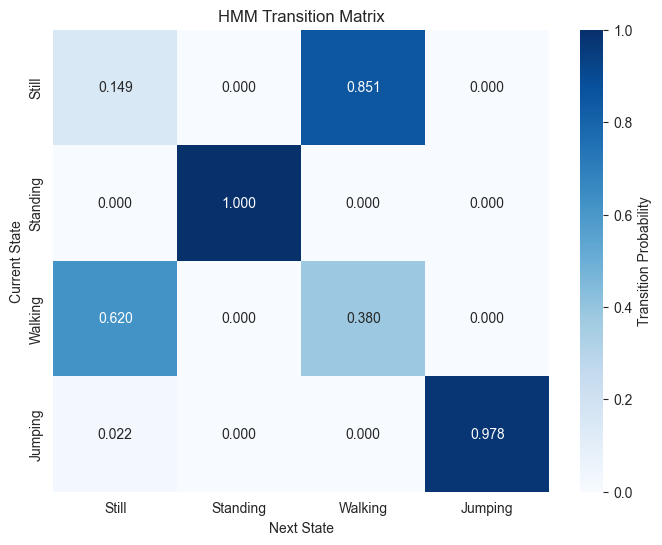

In [ ]:
# Plot Transition Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    model.transmat_,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=["Still", "Standing", "Walking", "Jumping"],
    yticklabels=["Still", "Standing", "Walking", "Jumping"],
    cbar_kws={'label': 'Transition Probability'}
)
plt.title("HMM Transition Matrix")
plt.xlabel("Next State")
plt.ylabel("Current State")

# Save for report
trans_plot = REPORT_PATH / "hmm_transition_matrix.png"
plt.savefig(trans_plot, dpi=150, bbox_inches='tight')
print(f"Transition matrix saved: {trans_plot}")
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

# Load test data and model
X_test_scaled = np.load(PROCESSED_PATH / "X_test.npy", allow_pickle=True).tolist()
y_test = np.load(PROCESSED_PATH / "y_test.npy", allow_pickle=True).tolist()
lengths_test = np.load(PROCESSED_PATH / "lengths_test.npy")
model = joblib.load(PROCESSED_PATH / "hmm_model.pkl")

print(f"Evaluating on {len(X_test_scaled)} test sessions → {sum(lengths_test)} windows")

Evaluating on 39 test sessions → 764 windows


In [ ]:
y_pred = []
y_true = []

for seq, true_labels in zip(X_test_scaled, y_test):
    pred_labels = model.predict(seq)
    y_pred.extend(pred_labels)
    y_true.extend([true_labels[0]] * len(pred_labels))

print(f"Total predictions: {len(y_pred)}")

Total predictions: 764


In [ ]:
state_means = model.means_
state_order = np.argsort(state_means[:, 9])

label_map = {
    state_order[0]: "Still",
    state_order[1]: "Standing",
    state_order[2]: "Walking",
    state_order[3]: "Jumping"
}

print("Learned State → Activity Mapping:")
for state, activity in label_map.items():
    print(f"  State {state} → {activity} (gyro_sma: {state_means[state, 9]:.3f})")

y_pred_mapped = [label_map[state] for state in y_pred]

Learned State → Activity Mapping:
  State 1 → Still (gyro_sma: -0.867)
  State 2 → Standing (gyro_sma: -0.091)
  State 0 → Walking (gyro_sma: -0.054)
  State 3 → Jumping (gyro_sma: 1.469)



CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Jumping      1.000     0.991     0.995       214
    Standing      0.000     0.000     0.000       170
       Still      0.613     1.000     0.760       269
     Walking      0.957     0.405     0.570       111

    accuracy                          0.688       764
   macro avg      0.643     0.599     0.581       764
weighted avg      0.635     0.688     0.629       764

Confusion matrix saved: c:\Users\TestSolutions\Desktop\HMM-Assignment\report\confusion_matrix.png


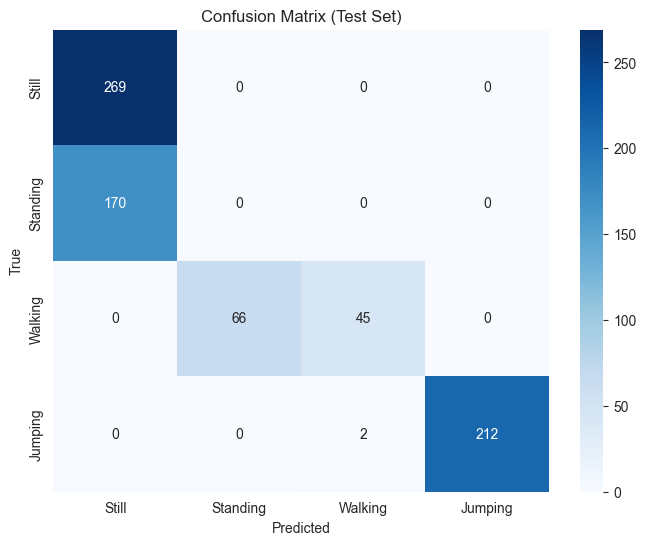

In [ ]:
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_true, y_pred_mapped, digits=3))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_mapped, 
                      labels=["Still", "Standing", "Walking", "Jumping"])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Still", "Standing", "Walking", "Jumping"],
            yticklabels=["Still", "Standing", "Walking", "Jumping"])
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")

cm_plot = REPORT_PATH / "confusion_matrix.png"
plt.savefig(cm_plot, dpi=150, bbox_inches='tight')
print(f"Confusion matrix saved: {cm_plot}")
plt.show()

In [ ]:
def sensitivity_specificity(cm, label):
    idx = ["Still", "Standing", "Walking", "Jumping"].index(label)
    tp = cm[idx, idx]
    fn = cm[idx, :].sum() - tp
    tn = cm.sum() - (cm[idx, :].sum() + cm[:, idx].sum() - tp)
    fp = cm[:, idx].sum() - tp
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    return sens, spec

print("\nPER-CLASS METRICS")
print("-" * 50)
for label in ["Still", "Standing", "Walking", "Jumping"]:
    sens, spec = sensitivity_specificity(cm, label)
    print(f"{label:9}: Sensitivity = {sens:.3f}, Specificity = {spec:.3f}")


PER-CLASS METRICS
--------------------------------------------------
Still    : Sensitivity = 1.000, Specificity = 0.657
Standing : Sensitivity = 0.000, Specificity = 0.889
Walking  : Sensitivity = 0.405, Specificity = 0.997
Jumping  : Sensitivity = 0.991, Specificity = 1.000


In [ ]:
metrics_df = classification_report(y_true, y_pred_mapped, output_dict=True)
metrics_df = pd.DataFrame(metrics_df).transpose()
metrics_df = metrics_df.round(3)
metrics_df.to_csv(REPORT_PATH / "classification_metrics.csv")
print("Metrics table saved: classification_metrics.csv")

Metrics table saved: classification_metrics.csv


In [ ]:
# Verify one test session
test_seq = X_test_scaled[0]
pred_states = model.predict(test_seq)
print(f"First 10 predictions: {pred_states[:10]}")
print(f"Mapped: {[label_map[s] for s in pred_states[:10]]}")

First 10 predictions: [3 3 3 3 3 3 3 3 3 3]
Mapped: ['Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping']
